<a href="https://colab.research.google.com/github/Inakshihansika/inakshihansika.github.io/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:27: SyntaxWarning: invalid escape sequence '\$'
<>:47: SyntaxWarning: invalid escape sequence '\$'
<>:27: SyntaxWarning: invalid escape sequence '\$'
<>:47: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_430/2940356426.py:27: SyntaxWarning: invalid escape sequence '\$'
  tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(",|\$", "", regex=True)
/tmp/ipykernel_430/2940356426.py:47: SyntaxWarning: invalid escape sequence '\$'
  gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",|\$", "", regex=True)


                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  
          Date Revenue
48  2010-09-30      31
49  2010-06-30      28
50  2010-03-31      21
52  2009-09-30      46
53  2009-06-30      27
                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620128  1.693350  1.603296  1.691666  76216000   
1 2002-02-14 00:00:00-05:00  1.71

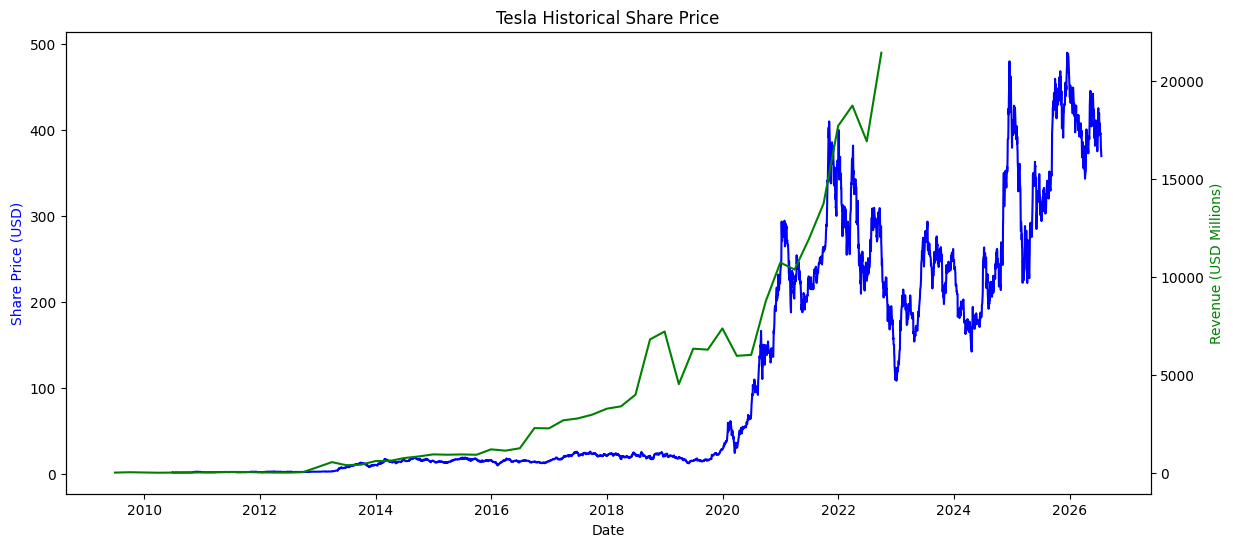

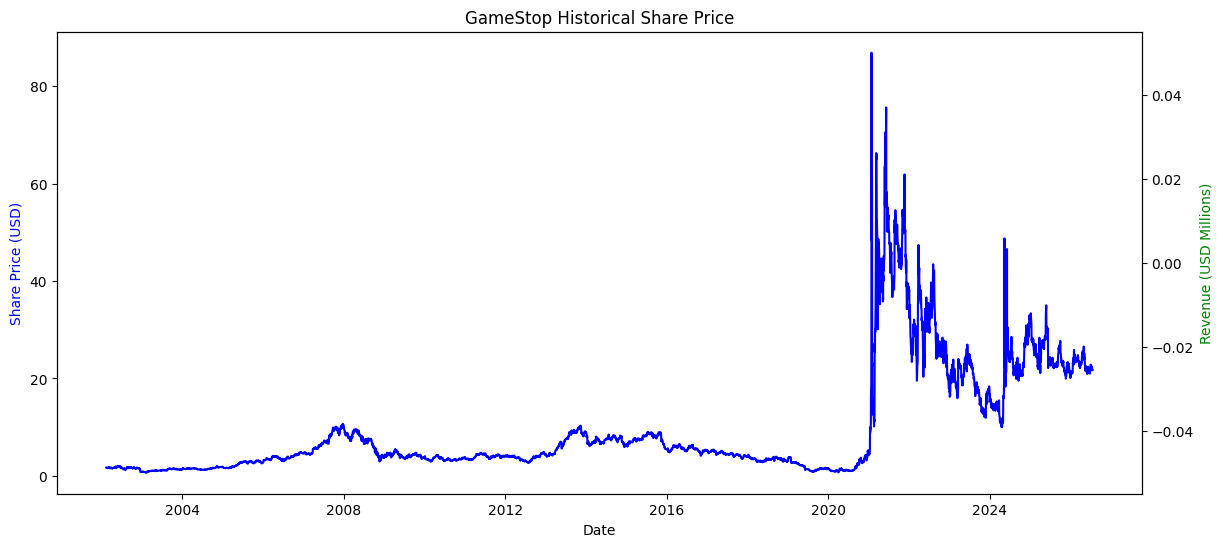

In [1]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

html_data = requests.get(url).text
soup = BeautifulSoup(html_data, "html.parser")

tables = soup.find_all("table")

tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in tables:
    if "Tesla Quarterly Revenue" in table.text:
        for row in table.find("tbody").find_all("tr"):
            cols = row.find_all("td")
            if len(cols) == 2:
                tesla_revenue.loc[len(tesla_revenue)] = [cols[0].text, cols[1].text]

tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(",|\$", "", regex=True)
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]
tesla_revenue.dropna(inplace=True)

print(tesla_data.head())
print(tesla_revenue.tail())

gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in tables:
    if "GameStop Quarterly Revenue" in table.text:
        for row in table.find("tbody").find_all("tr"):
            cols = row.find_all("td")
            if len(cols) == 2:
                gme_revenue.loc[len(gme_revenue)] = [cols[0].text, cols[1].text]

gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",|\$", "", regex=True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]
gme_revenue.dropna(inplace=True)

print(gme_data.head())
print(gme_revenue.tail())

def make_graph(stock_data, revenue_data, stock):
    stock_data = stock_data.copy()
    revenue_data = revenue_data.copy()

    stock_data["Date"] = pd.to_datetime(stock_data["Date"])
    revenue_data["Date"] = pd.to_datetime(revenue_data["Date"])
    revenue_data["Revenue"] = revenue_data["Revenue"].astype(float)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.plot(stock_data["Date"], stock_data["Close"], color="blue")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Share Price (USD)", color="blue")
    ax1.set_title(stock + " Historical Share Price")

    ax2 = ax1.twinx()
    ax2.plot(revenue_data["Date"], revenue_data["Revenue"], color="green")
    ax2.set_ylabel("Revenue (USD Millions)", color="green")

    plt.show()

make_graph(tesla_data, tesla_revenue, "Tesla")
make_graph(gme_data, gme_revenue, "GameStop")